In [1]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib



WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Get player details


In [2]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

players_preds = players_preds.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = players_preds.columns.tolist()

In [3]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [4]:
gw=35
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()
data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_24_25_test = data_23_24[data_23_24['event'] > gw]



joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols_gk]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['ownership_percent']
def_select_by = def_data['ownership_percent']
mid_select_by = mid_data['ownership_percent']
fwd_select_by = fwd_data['ownership_percent']

# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon



gk_data = gk_data.drop(columns='ownership_percent')
def_data = def_data.drop(columns='ownership_percent')
mid_data = mid_data.drop(columns='ownership_percent')
fwd_data = fwd_data.drop(columns='ownership_percent')

In [5]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

print(gk_data.shape)
X_gk = scaler_gk.fit_transform(gk_data.values)
X_def = scaler_def.fit_transform(def_data.values)
X_mid = scaler_mid.fit_transform(mid_data.values)
X_fwd = scaler_fwd.fit_transform(fwd_data.values)

# save standardscaler model
joblib.dump(scaler_gk, "scaler_gk.pkl")
joblib.dump(scaler_def, "scaler_def.pkl")
joblib.dump(scaler_mid, "scaler_mid.pkl")
joblib.dump(scaler_fwd, "scaler_fwd.pkl")


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

# save pca mode;
joblib.dump(pca_gk, "pca_gk.pkl")
joblib.dump(pca_def, "pca_def.pkl")
joblib.dump(pca_mid, "pca_mid.pkl")
joblib.dump(pca_fwd, "pca_fwd.pkl")

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

(440, 87)
Original shape: (440, 87) (2122, 109) (2898, 109) (959, 109)
Reduced shape: (440, 36) (2122, 43) (2898, 41) (959, 40)


In [6]:


def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        betas = pm.Normal("betas", mu=0, sigma=10, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas))

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        p_obs = pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=1)
        print("✅ Model fitting complete.")

    return trace

In [7]:
# Fit the model to get beta estimates
trace_gk = fit_dirichlet_regression(X_gk_pca, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 89 seconds.


✅ Model fitting complete.


In [8]:
joblib.dump(trace_gk, './trace_gk')

['./trace_gk']

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.05,0.01,-0.06,-0.04,0.0,0.0,19814.85,9601.58,1.0
betas[1],0.16,0.01,0.15,0.18,0.0,0.0,19980.14,9649.51,1.0
betas[2],0.01,0.01,-0.01,0.03,0.0,0.0,18227.18,10066.65,1.0
betas[3],-0.03,0.01,-0.05,-0.01,0.0,0.0,18323.08,8864.77,1.0
betas[4],0.04,0.01,0.01,0.06,0.0,0.0,15689.95,9319.08,1.0
betas[5],0.01,0.01,-0.01,0.03,0.0,0.0,18752.43,10204.33,1.0
betas[6],0.06,0.01,0.03,0.08,0.0,0.0,20006.83,9383.68,1.0
betas[7],-0.02,0.01,-0.05,0.00,0.0,0.0,19044.98,9341.37,1.0
betas[8],0.17,0.02,0.15,0.20,0.0,0.0,20963.46,10305.10,1.0
betas[9],-0.08,0.02,-0.11,-0.06,0.0,0.0,18347.98,9794.94,1.0


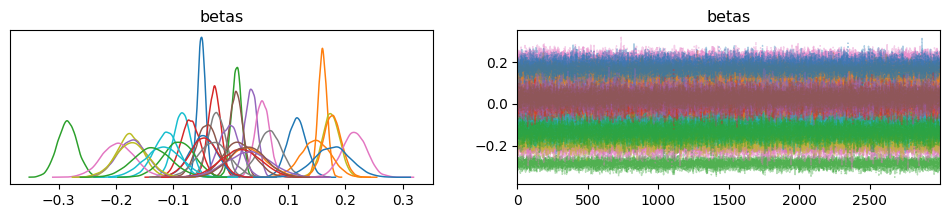

In [9]:
# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 172 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

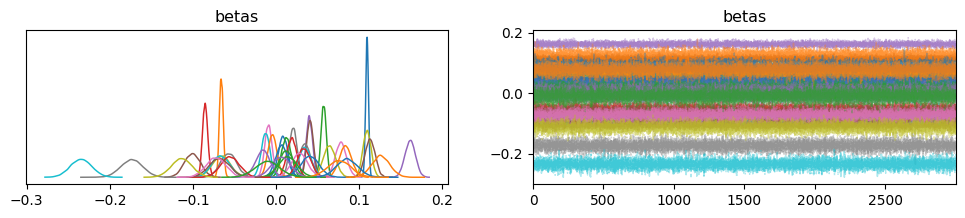

In [10]:
# Fit the model to get beta estimates
trace_def = fit_dirichlet_regression(X_def_pca, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

trace_def
az.plot_trace(trace_def, combined=True)

In [11]:
X_mid_pca.shape, mid_probs.shape

((2898, 41), (2898,))

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 188 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

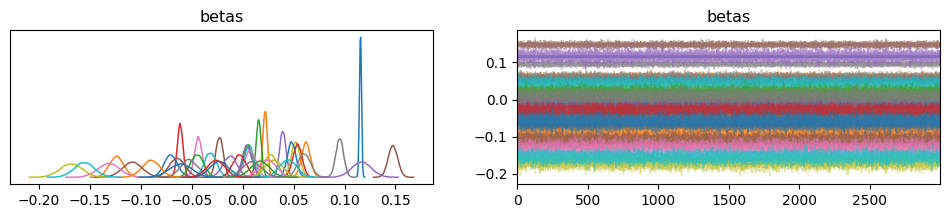

In [12]:
# Fit the model to get beta estimates
trace_mid = fit_dirichlet_regression(X_mid_pca, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

trace_mid
az.plot_trace(trace_mid, combined=True)

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 84 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

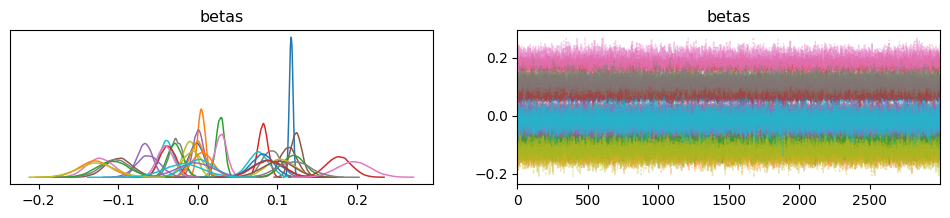

In [13]:
# Fit the model to get beta estimates
trace_fwd = fit_dirichlet_regression(X_fwd_pca, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

trace_fwd
az.plot_trace(trace_fwd, combined=True)

In [14]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./gk_beta_1.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./def_beta_1.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./mid_beta_1.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./fwd_beta_1.csv', index=False)

## Use betas


## Simulate selection probs


In [15]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

# simulate_observed_probs(X_gk_pca)

### Get betas


In [16]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=2000,
            # tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [17]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()

# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_gk_pca)
joblib.dump(beta_gk, './beta_gk_')


Number of Players: 440, Number of Features: 36


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 242 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.12270995  0.42396675  0.27402938  0.07538473 -0.23374064 -0.2794808
 -0.37045614  0.34168005  0.04887158  0.2578464  -0.36785614  0.48528382
  0.37180342 -0.19020285 -0.29691039 -0.2960928  -0.17113779  0.02237262
 -0.07867495 -0.16304366  0.14537079 -0.33149686 -0.14687965 -0.15410783
 -0.0432817   0.2813874  -0.21602083  0.02555152  0.06968558 -0.4752239
  0.07266577 -0.30684506 -0.38731885  0.41129756  0.49885478  0.20467987]


['./beta_gk_']

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

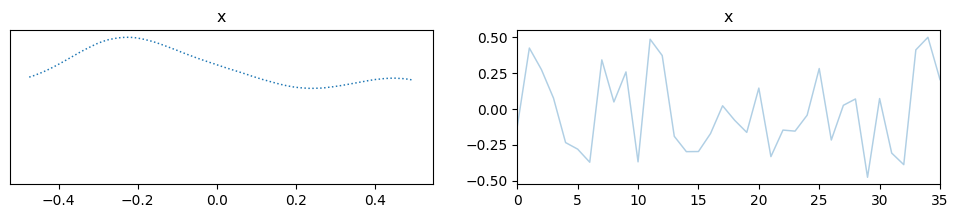

In [18]:
az.plot_trace(beta_gk, combined=True)


In [19]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2122, Number of Features: 43


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 257 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.11690009  0.43672297  0.22054022  0.10463144 -0.3238674  -0.34526328
 -0.42271472  0.37072802  0.10858282  0.16854279 -0.3698187   0.43587416
  0.31135162 -0.26970663 -0.3010874  -0.30996926 -0.18724828  0.0203619
 -0.07486562 -0.20094221  0.10962957 -0.34362096 -0.20458853 -0.12687493
 -0.05753199  0.25730102 -0.30478652 -0.02265174  0.13960267 -0.39581525
  0.13523696 -0.3361532  -0.41335511  0.45205574  0.43319441  0.31730587
 -0.19626003 -0.43032897  0.1742935  -0.05176517 -0.36028075 -0.00151918
 -0.46460959]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

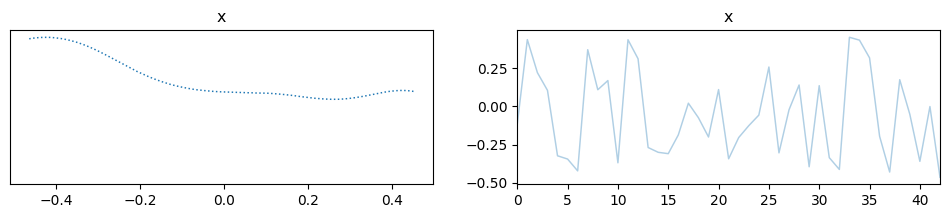

In [20]:
az.plot_trace(beta_def, combined=True)

In [21]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 2898, Number of Features: 41


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 653 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.12326171  0.44451975  0.22865128  0.09899139 -0.33835288 -0.34265241
 -0.44020645  0.35965534  0.107341    0.20569217 -0.46381026  0.46175998
  0.31832112 -0.28514579 -0.31756801 -0.3080264  -0.19624127  0.02088804
 -0.06925322 -0.20371195  0.11351118 -0.36013564 -0.20815596 -0.12794809
 -0.03831035  0.27523118 -0.30340066  0.00908833  0.08674268 -0.44711933
  0.10308812 -0.30668989 -0.42792858  0.4455195   0.47147585  0.31400574
 -0.19849223 -0.39177754  0.18526428 -0.05354548 -0.36713705]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

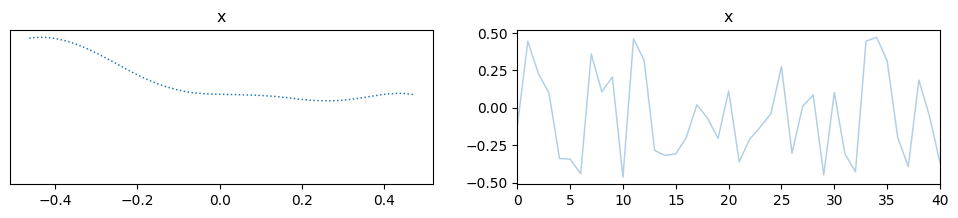

In [22]:
az.plot_trace(beta_mid, combined=True)

In [23]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 959, Number of Features: 40


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 174 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.11883291  0.43742194  0.23200976  0.09128777 -0.33290786 -0.33569003
 -0.43084065  0.35879053  0.08876293  0.20117099 -0.46769104  0.45376517
  0.33327007 -0.27724348 -0.30794986 -0.30913834 -0.18799654  0.02299546
 -0.06834409 -0.2036335   0.11873086 -0.35739329 -0.20400495 -0.12992369
 -0.04966778  0.28294102 -0.29353483  0.01582834  0.09393152 -0.45466658
  0.12301367 -0.31910928 -0.42323262  0.44473818  0.45114191  0.29566475
 -0.19345212 -0.38813805  0.16728412 -0.06080676]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

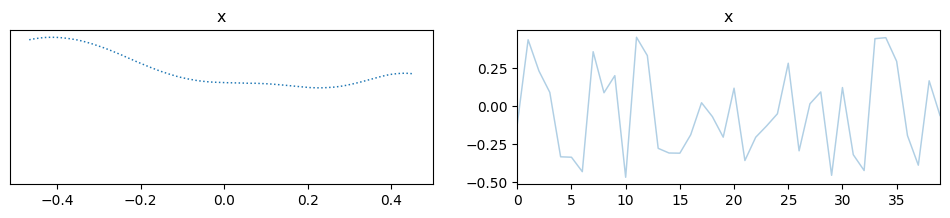

In [24]:
az.plot_trace(beta_fwd, combined=True)

In [25]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)